In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
import utils_2Q_gate_zp as ut
import qutip as qt
import scqubits as scq
from scipy.ndimage import gaussian_filter
import scipy as sp
from IPython.display import display, Math
from multiprocessing import Pool

#### Drag in 4-level system

In [2]:
drive_phi, drive_theta = False, True
truc1 = 30
n_cpu = 100

In [3]:
EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 100)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=30, truncated_dim=truc1)
n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc1)
n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc1)
n_Phi = 2*np.pi * qt.Qobj(n_phi)
n_Theta = 2*np.pi * qt.Qobj(n_theta)

evals = 2*np.pi * zero_pi.eigenvals(evals_count=truc1)
evals = evals - evals[0]
H0 = qt.Qobj(np.diag(evals))
if drive_phi:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = n_Phi
if drive_theta:
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    drive_term = n_Theta
if drive_phi and drive_theta:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = 0.976*n_Phi+ 0.024*n_Theta

#### Population transfer

In [4]:
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [39.991886,  0.104909, 0.028041, 0.002101, 0.003946]
hilbert_space = np.arange(truc1).tolist()
tlist = np.linspace(0, tg,  num=3* int(np.max([tg, len(hilbert_space) ]) ) )  # total time

pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        'alpha_A': 0}

H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, ut.drag_A],
                        [drive_truc, ut.drive_gauss_B],]

truc2 = len(hilbert_space)
states = [qt.basis(truc2, i) for i in range(truc2)]

options = qt.Options(store_states=True)
result = {}
index_2state = hilbert_space.index(2)
logi_state = [0, index_2state]
tlist_se = np.linspace(0, tg, 200)
for jdx, state_j in enumerate(logi_state):
    result[jdx] = qt.mesolve(
        H_qbt_drive,
        states[state_j],
        tlist_se,
        e_ops=[state * state.dag() for state in states],
        args=pulse_args,
        options=qt.Options(store_states=True, nsteps=1e4)  )

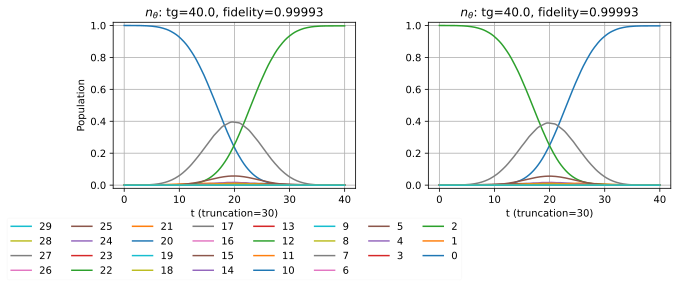

In [5]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        # if state in [0,2,7,25]:
        ax[jdx].plot(tlist_se, gaussian_filter( np.array(res).flatten(), 3) , label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    ax[jdx].set_ylim(-0.02,1.02)
    ax[jdx].grid()
    ax[jdx].set_xlabel(f't (truncation={truc1})')
    ax[jdx].set_title(f'$n_\\theta$: tg={np.round(tg,1)}, fidelity=0.99993')
    # ax[jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend( handles[::-1],labels[::-1], ncol=8,
            loc='upper center', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)

### Fidelity

In [8]:
nsteps = 1e9
def sesolve_parallel(argz):
    H, psi0, tlist, pulse_args, options = argz
    return psi0, qt.sesolve(H, qt.basis(H[0].shape[0], psi0), tlist, options=options, args=pulse_args)

def xgate_fidelity_fast(argz):
    [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
    drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B] = argz

    states = [qt.basis(len(hilbert_space), i) for i in range(len(hilbert_space))]
    H0_truc = ut.truncate_2(H0, hilbert_space)
    drive_truc = ut.truncate_2(drive_term, hilbert_space)
    H_qbt_drive = [H0_truc, [drive_truc, ut.drag_A],
                            [drive_truc, ut.drag_B],]

    pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': alpha_A,
             'alpha_B': alpha_B }
    tlist = np.linspace(0, tg,  num=100)  # total time
    options = qt.Options(num_cpus=1, nsteps=nsteps)

    sesolve_args = []
    logical_states = [0, 2]
    logical_idx = [hilbert_space.index(s) for s in logical_states]
    for i in logical_idx:
        sesolve_args.append([H_qbt_drive, i, tlist, pulse_args, options])

    prop = np.zeros((len(hilbert_space), len(logical_states)), dtype=np.complex128)
    if n_cpu > 1:
        pool = Pool(processes=n_cpu)
        for i, res in pool.imap_unordered(sesolve_parallel, sesolve_args):
            prop[:, logical_idx.index(i)] = res.states[-1].full().flatten()
    for se_arg in sesolve_args:
        i, res = sesolve_parallel(se_arg)
        prop[:, logical_idx.index(i)] = res.states[-1].full().flatten()
    prop = qt.Qobj(prop)

    Uc = ut.truncate_2(prop, [hilbert_space.index(psi) for psi in logical_states])
    fidelity = qt.average_gate_fidelity(Uc, target=qt.sigmax())
    return np.log10(1-fidelity)


def xgate_fidelity(argz):
    [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
    drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B] = argz

    states = [qt.basis(len(hilbert_space), i) for i in range(len(hilbert_space))]
    H0_truc = ut.truncate_2(H0, hilbert_space)
    drive_truc = ut.truncate_2(drive_term, hilbert_space)
    H_qbt_drive = [H0_truc, [drive_truc, ut.drag_A],
                            [drive_truc, ut.drag_B],]

    pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': alpha_A,
             'alpha_B': alpha_B }
    tlist = np.linspace(0, tg,  num=100)  # total time
    options =qt.Options(num_cpus=1, nsteps=nsteps)
    if n_cpu==1:
        props = qt.propagator(options=options,
                             H=H_qbt_drive,
                            t=tlist,
                            args=pulse_args,
                            )  # get the propagator at the final time step

        # num=100* int(np.max([tg, len(hilbert_space) ]))
        # options =qt.Options( nsteps=100*num)
        # prop = qt.propagator( H=H_qbt_drive,
        #                         t=tg,
        #                         args=pulse_args,
        #                         options=options,
        #                         # num_cpus=n_cpu,
        #                         # parallel=True,
        #                         )  # get the propagator at the final time step
    else:
        props = qt.propagator( H=H_qbt_drive,
                                t=tlist,
                                args=pulse_args,
                                options=options,
                                num_cpus=n_cpu,
                                parallel=True,
                                )  # get the propagator at the final time step
    prop = props[-1]
    # Max non logical + intermediate state population
    index_2 = hilbert_space.index(2)
    state_logi = [states[0], states[index_2]]
    Uc = qt.Qobj([ [prop.matrix_element(s1, s2) for s1 in state_logi]
            for s2 in state_logi  ])
    fidelity = qt.average_gate_fidelity(Uc, target=qt.sigmax())
    return np.log10(1-fidelity)

In [9]:
hspace_full = list(np.arange(20))
[tg, amp_A, amp_B, detune_A, detune_B] = [502.481, 0.0275548, 0.04704444, 0.0159511, 0.0173680]
n_cpu = 1
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_full, n_cpu, tg,
                amp_A, amp_B, detune_A, detune_B, 0, 0]


In [10]:
# f_fast = 1 - 10**xgate_fidelity_fast(argz)
# print('f_fast=', f_fast)

In [11]:
# f_old = 1 - 10**xgate_fidelity(argz)
# print('f_old=', f_old)


In [12]:
[H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B] = argz

states = [qt.basis(len(hilbert_space), i) for i in range(len(hilbert_space))]
H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, ut.drag_A],
                        [drive_truc, ut.drag_B],]

pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
            'alpha_A': alpha_A,
            'alpha_B': alpha_B }
tlist = np.linspace(0, tg,  num=100)  # total time
options = qt.Options(num_cpus=1, nsteps=nsteps)

sesolve_args = []
logical_states = [0, 2]
logical_idx = [hilbert_space.index(s) for s in logical_states]
for i in logical_idx:
    sesolve_args.append([H_qbt_drive, i, tlist, pulse_args, options])

prop = np.zeros((len(hilbert_space), len(logical_states)), dtype=np.complex128)
if n_cpu > 1:
    pool = Pool(processes=n_cpu)
    for i, res in pool.imap_unordered(sesolve_parallel, sesolve_args):
        prop[:, logical_idx.index(i)] = res.states[-1].full().flatten()
for se_arg in sesolve_args:
    i, res = sesolve_parallel(se_arg)
    prop[:, logical_idx.index(i)] = res.states[-1].full().flatten()
prop = qt.Qobj(prop)

Uc = ut.truncate_2(prop, [hilbert_space.index(psi) for psi in logical_states])
fidelity = qt.average_gate_fidelity(Uc, target=qt.sigmax())

In [ ]:
hilbert_space = [0, 2, 9, 10, 11, 15, 16, 18, 19, 25, 31, 33, 37,
                 46, 53, 55, 57, 69, 76, 77, 83, 91, 92, 95, 100, 121, 126, 154]
H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
drive_truc = drive_truc.tidyup(atol=1e-5)
# np.savetxt("n_theta_truc_4.txt", drive_truc.full(), delimiter=",", fmt="%.4f")  # Save as CSV
# np.savetxt("H0_truc_4.txt", H0_truc.full(), delimiter=",", fmt="%.4f")  # Save as CSV
